<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/04_icd_taller4_estimacion_distribuciones_JOHAN_ORDO%C3%91EZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:



1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **MÓDULO 1: OTRAS DISTRIBUCIONES TÍPICAS**
La distribución Normal y la Uniforme no son las únicas distribuciones de probabilidad típicas de variables aleatorias. En Ciencia de Datos, nos encontraremos con fenómenos que tienen comportamientos muy distintos que se modelan con otras distribuciones.

Por ejemplo, veamos estas tres distribuciones fundamentales:

1. **Distribución Exponencial:** Se usa en ingeniería de confiabilidad para modelar el tiempo hasta que una máquina falla, o en teoría de colas para modelar el tiempo de espera en la fila de un banco. El parámetro que identifica a la distribución exponencial es $\lambda$, el promedio de eventos (fallas o personas que llegan a la fila) por unidad de tiempo.

2. **Distribución Beta:** La distribución Beta es extremadamente flexible, siendo capaz de modelar distintos fenómenos dependiendo del valor de sus parámetros $\alpha$ y $\beta$. Por ejemplo, cuando $\alpha$ y $\beta$ son menores a 1 se puede usar para modelar la tasa de conversión de una campaña política donde los usuarios tienden a polarizarse.

3. **Distribución Log-Normal:** Se usa, por ejemplo, para modelar la distribución de la riqueza (pocas personas tienen muchísimo dinero), el tamaño de los archivos descargados de internet, o los precios de las acciones a largo plazo. Al igual que la distribución normal, sus parámetros son la media $\mu$ y la desviación estándar $\sigma$.

Veamos cómo son las Funciones de Densidad de Probabilidad (PDFs) de estas distribuciones a continuación.

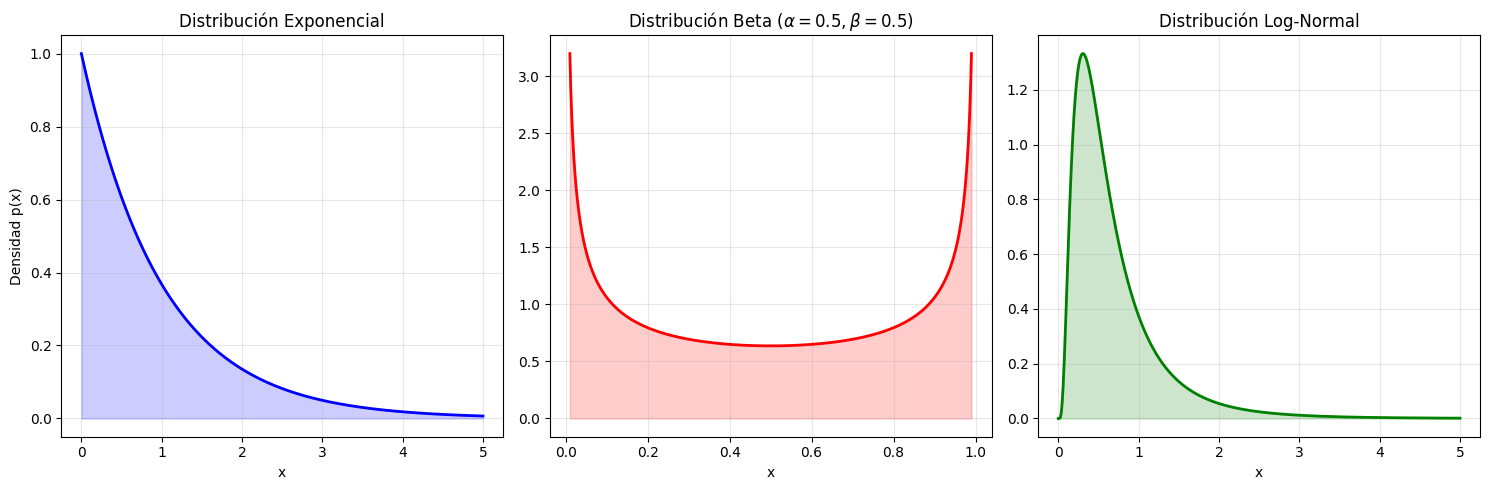

In [ ]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, beta, lognorm

# Configuramos el tamaño de la figura
plt.figure(figsize=(15, 5))

# 1. GRÁFICA: DISTRIBUCIÓN EXPONENCIAL (lambda = 1)
# Parámetros:
l = 1 # lambda = 1
# Gráfica:
plt.subplot(1, 3, 1) # (1 fila, 3 columnas, gráfica 1)
x_expon = np.linspace(0, 5, 1000)
pdf_expon = expon.pdf(x_expon, scale=1/l) # scale = 1/lambda
plt.plot(x_expon, pdf_expon, 'b-', lw=2)
plt.fill_between(x_expon, pdf_expon, alpha=0.2, color='blue')
plt.title('Distribución Exponencial')
plt.ylabel('Densidad p(x)')
plt.xlabel('x')
plt.grid(True, alpha=0.3)


# 2. GRÁFICA: DISTRIBUCIÓN BETA (alpha = 0.5, beta = 0.5)
# Parámetros:
a = 0.5 # alpha = 0.5
b = 0.5 # beta = 0.5
# Gráfica
plt.subplot(1, 3, 2)
# Evitamos el 0 y 1 exactos porque la densidad tiende a infinito en los bordes para alpha<1, beta<1
x_beta = np.linspace(0.01, 0.99, 1000)
pdf_beta = beta.pdf(x_beta, a, b)
plt.plot(x_beta, pdf_beta, 'r-', lw=2)
plt.fill_between(x_beta, pdf_beta, alpha=0.2, color='red')
plt.title(r'Distribución Beta ($\alpha=0.5, \beta=0.5$)')
plt.xlabel('x')
plt.grid(True, alpha=0.3)


# 3. GRÁFICA: DISTRIBUCIÓN LOG-NORMAL (mu = 0.7 , sigma = 0.6)
# Parámetros:
mu = 0.7
sigma = 0.6
# Gráfica
plt.subplot(1, 3, 3)
x_lognorm = np.linspace(0, 5, 1000)
# En Python, la función log-normal tiene otros parámetros: s y scale.
# Estos parámetros se calculan a partir de mu y sigma así:
s_calculado =  np.sqrt(np.log(1 + (sigma**2 / mu**2)))
scale_calculado = mu / np.sqrt(1 + (sigma**2 / mu**2))

pdf_lognorm = lognorm.pdf(x_lognorm, s=s_calculado, scale=scale_calculado)
plt.plot(x_lognorm, pdf_lognorm, 'g-', lw=2)
plt.fill_between(x_lognorm, pdf_lognorm, alpha=0.2, color='green')
plt.title('Distribución Log-Normal')
plt.xlabel('x')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# **MÓDULO 2: MOMENTOS DE UNA VARIABLE ALEATORIA**

Si bien las gráficas de las PDFs nos dan la idea exacta de cómo se comporta una variable aleatoria (qué valores son los más probables, dónde está sesgada, etc.), a menudo no podemos o no queremos estar graficando cada variable.

En Ciencia de Datos, es conveniente resumir la gráfica en **características numéricas** que nos den una idea de la forma de la distribución sin necesidad de verla. Estos descriptores se conocen como **Momentos**.

Los momentos son, literalmente, la huella digital de una variable aleatoria. Si conoces todos los momentos de una variable, conoces exactamente su distribución.

### Fórmulas de los Momentos
Si conocemos la función de densidad $f_X(x)$, el $n$-ésimo Momento *Central* (*central* se refiere a que el cálculo se realiza respecto a la media $\mu$), denotado como $m_n$, se calcula integrando:
$$ m_n = E[(X-\mu)^n] = \int_{-\infty}^{\infty} (x-\mu)^n \cdot f(x) dx $$

Pero si estamos trabajando empíricamente con **datos extraídos de una muestra** (tamaño $N$), estimamos los momentos así:
$$ m_n = \frac{1}{N} \sum_{i=1}^{N} (x_i-\mu)^n $$

### Los 4 Momentos Principales
1. **Media / Valor Esperado (1er Momento):** Indica el "centro de masa" o tendencia central de la distribución.
2. **Varianza (2do Momento *Central*):** Mide qué tan esparcidos o dispersos están los valores alrededor de la media.
3. **Sesgo / Asimetría (3er Momento *Central*):** Indica hacia dónde está "inclinada" o sesgada la distribución. (0 es simétrica, positivo es cola hacia la derecha, negativo cola hacia la izquierda).
4. **Curtosis (4to Momento *Central*):** Mide el "peso" o grosor de las colas de la distribución en comparación con una distribución normal. Valores positivos y altos de curtosis significan que los eventos extremos (outliers) son más probables de lo que dictaría una campana de Gauss. Valores negativos indican una distribución más plana y con colas ligeras.

Cabe resaltar que el **Sesgo** y la **Curtosis** se suelen *''estandarizar''* para que no dependan de las unidades de la variable aleatoria (por ejemplo, para que sea comparable el sesgo obtenido con una distribución de peso en kilos con los de una distribución de alturas en metros de forma directa). La estandarización usa las siguientes fórmulas:

*   **Sesgo Estandarizado**$\displaystyle\ =\frac{m_3}{\sigma^3}$
*   **Curtosis Estandarizada**$\displaystyle\ =\frac{m_4}{\sigma^4}-3$:





In [ ]:
# ==========================================
# --- INTUICIÓN VISUAL ---
# ==========================================

# ANTES de hacer cálculos, mira atentamente las 3 gráficas que generamos arriba.
# Usa tu intuición para responder las siguientes preguntas.
# Reemplaza el texto "[TU RESPUESTA AQUÍ]" con tu elección:
# Opciones válidas: 'Exponencial', 'Beta' o 'Log-Normal'

print("1. La distribución con mayor Media parece ser: Exponencial")
print("2. La distribución con mayor Varianza parece ser: Exponencial")
print("3. La distribución con mayor Asimetría (cola derecha más pesada) es: Log-Normal")
print("4. La distribución con mayor Curtosis (eventos extremos atípicos) es: Log-Normal")


1. La distribución con mayor Media parece ser: Exponencial
2. La distribución con mayor Varianza parece ser: Exponencial
3. La distribución con mayor Asimetría (cola derecha más pesada) es: Log-Normal
4. La distribución con mayor Curtosis (eventos extremos atípicos) es: Log-Normal


In [ ]:
# ==========================================
# --- VERIFICACIÓN DE MOMENTOS CON PYTHON ---
# ==========================================
# Ahora, usemos Python para calcular los Momentos a partir de una
# simulación grande de datos. Así validaremos tus respuestas anteriores.

from scipy.stats import skew, kurtosis

N = 100000 # Tamaño de la muestra simulada

# 1. Generamos los datos aleatorios para cada distribución
datos_expon = expon.rvs(scale=1/l, size=N)
datos_beta = beta.rvs(a, b, size=N)
datos_lognorm = lognorm.rvs(s=s_calculado, scale=scale_calculado, size=N)

# Creamos un diccionario iterativo para calcular y mostrar todo en orden
distribuciones = {
    "Exponencial": datos_expon,
    "Beta": datos_beta,
    "Log-Normal": datos_lognorm
}

print("--- RESULTADOS DE LOS MOMENTOS EMPÍRICOS ---\n")

for nombre, datos in distribuciones.items():
    # Cálculo usando NumPy y SciPy
    m_media = np.mean(datos)
    m_varianza = np.var(datos)
    m_asimetria = skew(datos) # Calcula el sesgo estandarizado
    m_curtosis = kurtosis(datos) # Calcula la curtosis estandarizada

    skew

    print(f"Distribución {nombre}:")
    print(f"  - Media      (1er): {m_media:.4f}")
    print(f"  - Varianza   (2do): {m_varianza:.4f}")
    print(f"  - Sesgo      (3er): {m_asimetria:.4f}")
    print(f"  - Curtosis   (4to): {m_curtosis:.4f}\n")

# ¿Acertaste tus predicciones iniciales?


--- RESULTADOS DE LOS MOMENTOS EMPÍRICOS ---

Distribución Exponencial:
  - Media      (1er): 1.0045
  - Varianza   (2do): 1.0133
  - Sesgo      (3er): 1.9818
  - Curtosis   (4to): 5.6657

Distribución Beta:
  - Media      (1er): 0.4991
  - Varianza   (2do): 0.1246
  - Sesgo      (3er): 0.0056
  - Curtosis   (4to): -1.4988

Distribución Log-Normal:
  - Media      (1er): 0.6988
  - Varianza   (2do): 0.3589
  - Sesgo      (3er): 3.2389
  - Curtosis   (4to): 23.1056



# **Módulo 3: Estimación de una Distribución a partir de Datos**

En Ciencia de Datos, el proceso suele ser inverso al que acabamos de hacer: **no conocemos la distribución teórica de antemano**. Lo único que tenemos es una tabla con datos crudos y nuestro trabajo es descubrir qué distribución los generó.

### Proceso de Ajuste (Fitting)
1. **Obtener los datos y graficarlos:** Hacer un histograma para ver la forma.
2. **Calcular los Momentos:** Extraer la media, varianza, sesgo y curtosis de la muestra.
3. **Seleccionar Distribuciones Candidatas:** Usando la información de la gráfica y de los momentos calculados (ej. si el sesgo es muy positivo, descartamos la Normal y pensamos en una Exponencial o Log-Normal).
4. **Ajustar (Fit) los Parámetros:** Encontrar los parámetros que hacen que la curva teórica se adapte lo mejor posible a nuestro histograma.
5. Evaluar qué tan bien resulta el ajuste. Inicialmente, una inspección visual es útil. Luego, puede usarse una prueba de bondad como la **Prueba Kolmogorov-Smirnov (K-S)**. Esta calcula la distancia máxima entre la curva teórica y los datos reales. Cuanto más cercano a $0$ sea el estadístico K-S, mejor es el ajuste.

Vamos a aplicar este proceso a un **Dataset Real**. Analizaremos el total de las cuentas (`total_bill`) pagadas en un restaurante.

Primeras 5 cuentas registradas: [16.99 10.34 21.01 23.68 24.59]
Total de datos (N): 244

--- MOMENTOS EMPÍRICOS DE LAS CUENTAS ---
Media     : $19.79
Varianza  : 78.93
Sesgo     : 1.1262
Curtosis  : 1.1692


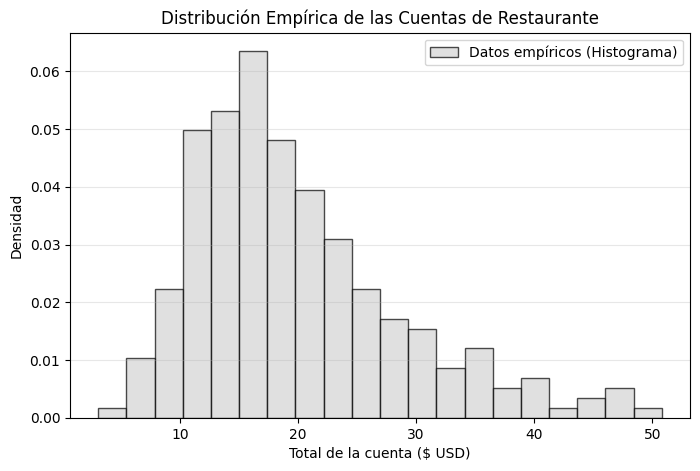

In [ ]:
# Importamos seaborn que contiene datasets de prueba
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# 1. CARGAMOS EL DATASET REAL
# Este dataset contiene información sobre cuentas de restaurante y propinas
df_restaurante = sns.load_dataset('tips')

# Extraemos la variable que nos interesa: Total de la cuenta (en dólares)
datos_cuentas = df_restaurante['total_bill'].dropna().values

print("Primeras 5 cuentas registradas:", datos_cuentas[:5])
print("Total de datos (N):", len(datos_cuentas))

# ==========================================
# PASO 1 y 2: EXPLORACIÓN Y MOMENTOS
# ==========================================

# Calculamos los 4 momentos a partir de los datos
media = np.mean(datos_cuentas)
var = np.var(datos_cuentas)
sesgo = skew(datos_cuentas)
curtosis = kurtosis(datos_cuentas)

print("\n--- MOMENTOS EMPÍRICOS DE LAS CUENTAS ---")
print(f"Media     : ${media:.2f}")
print(f"Varianza  : {var:.2f}")
print(f"Sesgo     : {sesgo:.4f}")
print(f"Curtosis  : {curtosis:.4f}")

# Graficamos el histograma para ver la forma empírica
plt.figure(figsize=(8, 5))
# density=True hace que el área del histograma sume 1 (lo convierte en una Función de Densidad - PDF)
plt.hist(datos_cuentas, bins=20, density=True, color='lightgray', edgecolor='black', alpha=0.7, label='Datos empíricos (Histograma)')
plt.title('Distribución Empírica de las Cuentas de Restaurante')
plt.xlabel('Total de la cuenta ($ USD)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- PREGUNTA ---
# ¿Crees que una Distribución Normal clásica sería un buen modelo predictivo aquí? ¿por qué?


# PREGUNTA
**¿Crees que una Distribución Normal clásica sería un buen modelo predictivo aquí? ¿por qué?**

**RESPUESTA :** No, la Distribución Normal no sería un modelo adecuado en este caso. Aunque la llamada “Campana de Gauss” es fundamental en estadística, suponer normalidad aquí conduciría a predicciones incorrectas. En particular, la Distribución Normal no representa bien los valores extremos (especialmente las cuentas altas) y, además, permitiría valores negativos, lo cual es imposible en este tipo de datos.

Adicionalmente, el sesgo positivo observado (aproximadamente 1.12) confirma que la distribución está claramente inclinada hacia la derecha. Dado que la Distribución Normal solo es apropiada cuando el sesgo es cercano a cero, este resultado refuerza que no es un modelo adecuado para describir ni predecir el comportamiento de las cuentas.

### Evaluación de Candidatos: Normal vs. Log-Normal

Al analizar los momentos, notamos un **sesgo positivo fuerte ($>1$)**. Esto nos indica una cola pesada hacia la derecha (dado, por ejemplo, a que algunos clientes piden botellas de vino caras que inflan la cuenta).

En Python, la librería `scipy.stats` tiene un método llamado `.fit()`. Este método toma los datos empíricos y, utilizando técnicas de optimización (como el *Método de Máxima Verosimilitud*), calcula automáticamente cuáles deberían ser los parámetros de la curva para ajustarse "lo mejor posible" al histograma empírico.

Vamos a enfrentar a dos modelos candidatos:
1. La Distribución Normal.
2. La Distribución Log-Normal.

*¿A qué modelo le apuestas?*

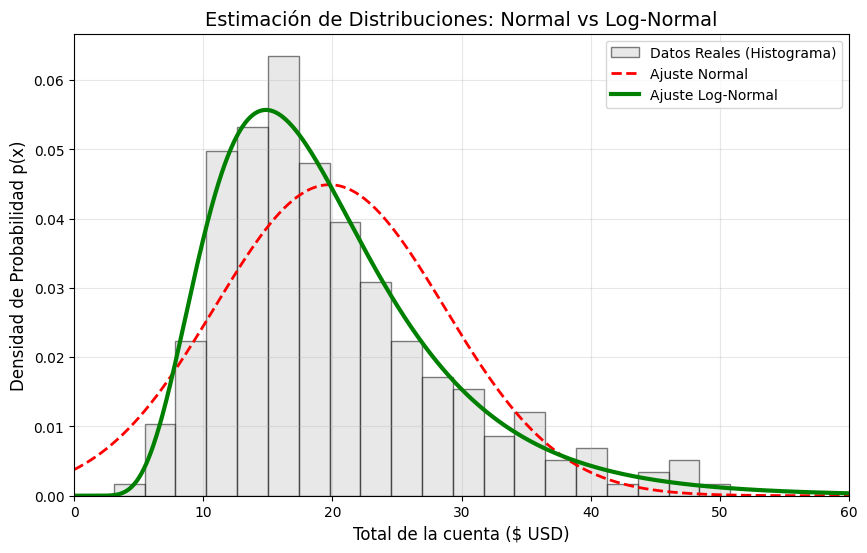


--- PRUEBA DE BONDAD DE AJUSTE (KOLMOGOROV-SMIRNOV) ---
Modelo Normal     -> Distancia K-S: 0.1188
Modelo Log-Normal -> Distancia K-S: 0.0358

--- CONCLUSIÓN ---
Visualmente notamos que la curva roja (Normal) abarca valores negativos imposibles y falla en la cola, subestimando la cantidad de cuentas caras.
Además, la distancia K-S de la Log-Normal es MENOR que la de la Normal.
Por lo tanto, la Log-Normal es matemáticamente un mejor modelo para estos datos.


In [ ]:
from scipy.stats import norm, lognorm

# ==========================================
# PASO 3 y 4: AJUSTE (FIT) DE DISTRIBUCIONES
# ==========================================

# 1. Ajustamos la Distribución Normal
# .fit() devuelve los parámetros estimados: (media_estimada, desviacion_estimada)
parametros_normal = norm.fit(datos_cuentas)
media_norm, std_norm = parametros_normal

# 2. Ajustamos la Distribución Log-Normal
# .fit() devuelve: (forma 's', ubicacion 'loc', escala 'scale')
parametros_lognorm = lognorm.fit(datos_cuentas, floc=0) # Fijamos floc=0 porque las cuentas empiezan en $0
s_estimado, loc_estimado, scale_estimado = parametros_lognorm

# ==========================================
# PASO 5: VERIFICACIÓN VISUAL
# ==========================================

# Creamos un eje X continuo para trazar nuestras curvas teóricas (desde $0 hasta $60)
x_teorico = np.linspace(0, 60, 1000)

# Generamos los valores Y (las PDFs) usando los parámetros que acabamos de encontrar
pdf_normal = norm.pdf(x_teorico, loc=media_norm, scale=std_norm)
pdf_lognorm = lognorm.pdf(x_teorico, s=s_estimado, loc=loc_estimado, scale=scale_estimado)

# Graficamos todo
plt.figure(figsize=(10, 6))

# 1. El histograma real
plt.hist(datos_cuentas, bins=20, density=True, color='lightgray', edgecolor='black', alpha=0.5, label='Datos Reales (Histograma)')

# 2. La curva Normal
plt.plot(x_teorico, pdf_normal, 'r--', lw=2, label='Ajuste Normal')

# 3. La curva Log-Normal
plt.plot(x_teorico, pdf_lognorm, 'g-', lw=3, label='Ajuste Log-Normal')

plt.title('Estimación de Distribuciones: Normal vs Log-Normal', fontsize=14)
plt.xlabel('Total de la cuenta ($ USD)', fontsize=12)
plt.ylabel('Densidad de Probabilidad p(x)', fontsize=12)
plt.legend()
plt.grid(axis='both', alpha=0.3)

# Limitamos el eje X para que se vea igual que el histograma
plt.xlim(0, 60)
plt.show()

# ==========================================
# PASO 6: VERIFICACIÓN CUANTITATIVA (K-S TEST)
# ==========================================
from scipy.stats import kstest

print("\n--- PRUEBA DE BONDAD DE AJUSTE (KOLMOGOROV-SMIRNOV) ---")
# Probamos qué tan bien se ajusta la Normal
stat_norm, p_norm = kstest(datos_cuentas, 'norm', args=(media_norm, std_norm))
# Probamos qué tan bien se ajusta la Log-Normal
stat_lognorm, p_lognorm = kstest(datos_cuentas, 'lognorm', args=(s_estimado, loc_estimado, scale_estimado))

print(f"Modelo Normal     -> Distancia K-S: {stat_norm:.4f}")
print(f"Modelo Log-Normal -> Distancia K-S: {stat_lognorm:.4f}")

print("\n--- CONCLUSIÓN ---")
print("Visualmente notamos que la curva roja (Normal) abarca valores negativos imposibles y falla en la cola, subestimando la cantidad de cuentas caras.")
print("Además, la distancia K-S de la Log-Normal es MENOR que la de la Normal.")
print("Por lo tanto, la Log-Normal es matemáticamente un mejor modelo para estos datos.")

# ==========================================
# PREGUNTA: Cuál es la probabilidad de que la cuenta salga por entre $30 y $40 USD?
# - Aquí tu código que soluciona esta pregunta: -


# **Reto 1: Toma de Decisiones Financieras bajo Incertidumbre**

Hasta ahora hemos analizado variables aleatorias por separado. Sin embargo, en la vida real, los fenómenos interactúan entre sí.

### Contexto del Negocio
Una *Startup* de Inteligencia Artificial tiene un modelo de negocio que cobra una tarifa a los clientes por usar su API. A la vez, le cuesta dinero procesar esas peticiones en servidores de Amazon Web Services (AWS).

Se tienen dos variables aleatorias diarias:
1. **Los Ingresos Diarios ($I$):** Son muy estables y predecibles. Siguen una **Distribución Normal** con media $\mu = \$5.000$ y desviación estándar $\sigma = \$500$.
2. **Los Costos Diarios de AWS ($C$):** Dependen de picos de computación (por ejemplo, clientes subiendo archivos muy grandes). Siguen una **Distribución Log-Normal** fuertemente sesgada a la derecha. La mayoría de los días el costo es bajo, pero de vez en cuando hay picos muy altos. La media de la distribución es $\mu = \$3.830 $ y su desviación estándar es $\sigma = \$3.050 $.

El equipo financiero debe tomar una decisión entre estas opciones:

* **Opción A (Plan Variable):** Seguir pagando a AWS como se ha venido haciendo. Es decir, los costos se modelan a través de la **Log-Normal** descrita anteriormente.
* **Opción B (Plan Tarifa Plana):** AWS ofrece un seguro. Un pago fijo garantizado de **$\$4,200$** diarios. Tráfico ilimitado.

**Entregable:** Calcular mediante simulación (100000 días) la **Ganancia Diaria ($G = I - C$)** para ambas opciones y decidir cuál plan minimiza el riesgo de que la empresa pierda dinero en un día determinado ($G < 0$).

In [ ]:

# --- CÓDIGO PROBLEMA AWS ---

# =============================================================================
# SECCIÓN 1: IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import numpy as np
from scipy.stats import skew, kurtosis

# Semilla para reproducibilidad
np.random.seed(42)

# =============================================================================
# SECCIÓN 2: PARÁMETROS DEL PROBLEMA
# =============================================================================
N = 100000          # Número de días simulados

# Ingresos Diarios    →  Distribución Normal
I_MEDIA  = 5000     # μ = $5,000
I_SIGMA  = 500      # σ = $500

# Costos Diarios AWS  →  Distribución Log-Normal
C_MEDIA  = 3830     # media en el espacio original
C_SIGMA  = 3050     # desviación en el espacio original

# Conversión a parámetros de la normal subyacente de la Log-Normal
sigma_n2 = np.log(1 + (C_SIGMA / C_MEDIA) ** 2)
sigma_n  = np.sqrt(sigma_n2)
mu_n     = np.log(C_MEDIA) - sigma_n2 / 2

TARIFA_PLANA = 4200  # Opción B: pago fijo diario a AWS

# =============================================================================
# SECCIÓN 3: SIMULACIÓN MONTE CARLO
# =============================================================================
# Ingresos: iguales para ambas opciones
ingresos = np.random.normal(loc=I_MEDIA, scale=I_SIGMA, size=N)

# Costos Opción A: Log-Normal variable
costos_A = np.random.lognormal(mean=mu_n, sigma=sigma_n, size=N)

# Costos Opción B: tarifa plana fija
costos_B = np.full(N, TARIFA_PLANA)

# Ganancias diarias G = I - C
ganancia_A = ingresos - costos_A # Ganancias Opción A:
ganancia_B = ingresos - costos_B # Ganancias Opción B:

# =============================================================================
# SECCIÓN 4: ANÁLISIS ESTADÍSTICO
# =============================================================================
def analizar(ganancia, nombre):
    n = len(ganancia)
    dias_perdida  = np.sum(ganancia < 0)
    prob_perdida  = dias_perdida / n * 100.0
    return {
        "nombre"       : nombre,
        "media"        : float(np.mean(ganancia)),
        "mediana"      : float(np.median(ganancia)),
        "std"          : float(np.std(ganancia)),
        "var"          : float(np.var(ganancia)),
        "sesgo"        : float(skew(ganancia)),
        "curtosis"     : float(kurtosis(ganancia)),
        "dias_perdida" : int(dias_perdida),
        "prob_perdida" : float(prob_perdida),
        "min"          : float(np.min(ganancia)),
        "max"          : float(np.max(ganancia)),
    }

stats_A = analizar(ganancia_A, "Opción A — Plan Variable")
stats_B = analizar(ganancia_B, "Opción B — Tarifa Plana")

# =============================================================================
# SECCIÓN 5: IMPRESIÓN DE RESULTADOS EN CONSOLA
# =============================================================================
def imprimir_stats(s):
    print(f"\n{'='*65}")
    print(f"  {s['nombre']}")
    print(f"{'='*65}")
    # Valores monetarios → llevan $ y formato de miles
    print(f"  Ganancia media diaria   :  $ {s['media']:>12,.2f}")
    print(f"  Ganancia mediana        :  $ {s['mediana']:>12,.2f}")
    print(f"  Desviación estándar     :  $ {s['std']:>12,.2f}")
    print(f"  Varianza                :  $ {s['var']:>12,.2f}")
    print(f"  Ganancia mínima         :  $ {s['min']:>12,.2f}")
    print(f"  Ganancia máxima         :  $ {s['max']:>12,.2f}")
    # Valores adimensionales → sin $, solo número alineado
    print(f"  Sesgo                   :  {s['sesgo']:>13.4f}")
    print(f"  Curtosis                :  {s['curtosis']:>13.4f}")
    # Separador visual antes de la métrica de riesgo
    print(f"  {'-'*61}")
    print(f"  Días con pérdida (G<0)  :  {s['dias_perdida']:>8,d} de {N:,}")
    print(f"  Probabilidad pérdida    :  {s['prob_perdida']:>8.2f} %")
    print(f"{'='*65}")

imprimir_stats(stats_A)
prob_A_mejor_que_B = np.mean(ganancia_A > ganancia_B) * 100
print(f"  Probabilidad de que A tenga mayor ganancia que B: {prob_A_mejor_que_B:.2f}%")

imprimir_stats(stats_B)
prob_B_mejor_que_A = np.mean(ganancia_A < ganancia_B) * 100
print(f"  Probabilidad de que B tenga mayor ganancia que A: {prob_B_mejor_que_A:.2f}%")

# Decisión final (minimiza riesgo de pérdida)
print(f"\n{'='*65}")
print("  DECISIÓN FINANCIERA")
print(f"{'='*65}")
if stats_B["prob_perdida"] < stats_A["prob_perdida"]:
    reduccion = stats_A["prob_perdida"] - stats_B["prob_perdida"]
    print("  Se recomienda la OPCIÓN B (Tarifa Plana).")
    print(f"  Días con pérdida (G<0): Opción A= {stats_A['prob_perdida']:.2f}% y Opción B= {stats_B['prob_perdida']:.2f}%")
    print(f"  La OPCIÓN B, reduce el riesgo de pérdida en {reduccion:.2f} %")
elif stats_A["prob_perdida"] < stats_B["prob_perdida"]:
    reduccion = stats_B["prob_perdida"] - stats_A["prob_perdida"]
    print("  Se recomienda la OPCIÓN A (Plan Variable).")
    print(f"  Días con pérdida (G<0): Opción B= {stats_B['prob_perdida']:.2f}% y Opción A= {stats_A['prob_perdida']:.2f}%")
    print(f"  La OPCIÓN A, reduce el riesgo de pérdida en {reduccion:.2f} %")
else:
    print("  Ambas opciones tienen el mismo riesgo de pérdida.")
print(f"{'='*65}\n")



  Opción A — Plan Variable
  Ganancia media diaria   :  $     1,171.94
  Ganancia mediana        :  $     1,963.88
  Desviación estándar     :  $     3,061.30
  Varianza                :  $ 9,371,564.83
  Ganancia mínima         :  $   -67,703.44
  Ganancia máxima         :  $     6,146.02
  Sesgo                   :        -2.6457
  Curtosis                :        14.9266
  -------------------------------------------------------------
  Días con pérdida (G<0)  :    23,691 de 100,000
  Probabilidad pérdida    :     23.69 %
  Probabilidad de que A tenga mayor ganancia que B: 68.46%

  Opción B — Tarifa Plana
  Ganancia media diaria   :  $       800.48
  Ganancia mediana        :  $       801.32
  Desviación estándar     :  $       500.45
  Varianza                :  $   250,450.68
  Ganancia mínima         :  $    -1,432.80
  Ganancia máxima         :  $     3,039.54
  Sesgo                   :        -0.0018
  Curtosis                :        -0.0080
  -------------------------------

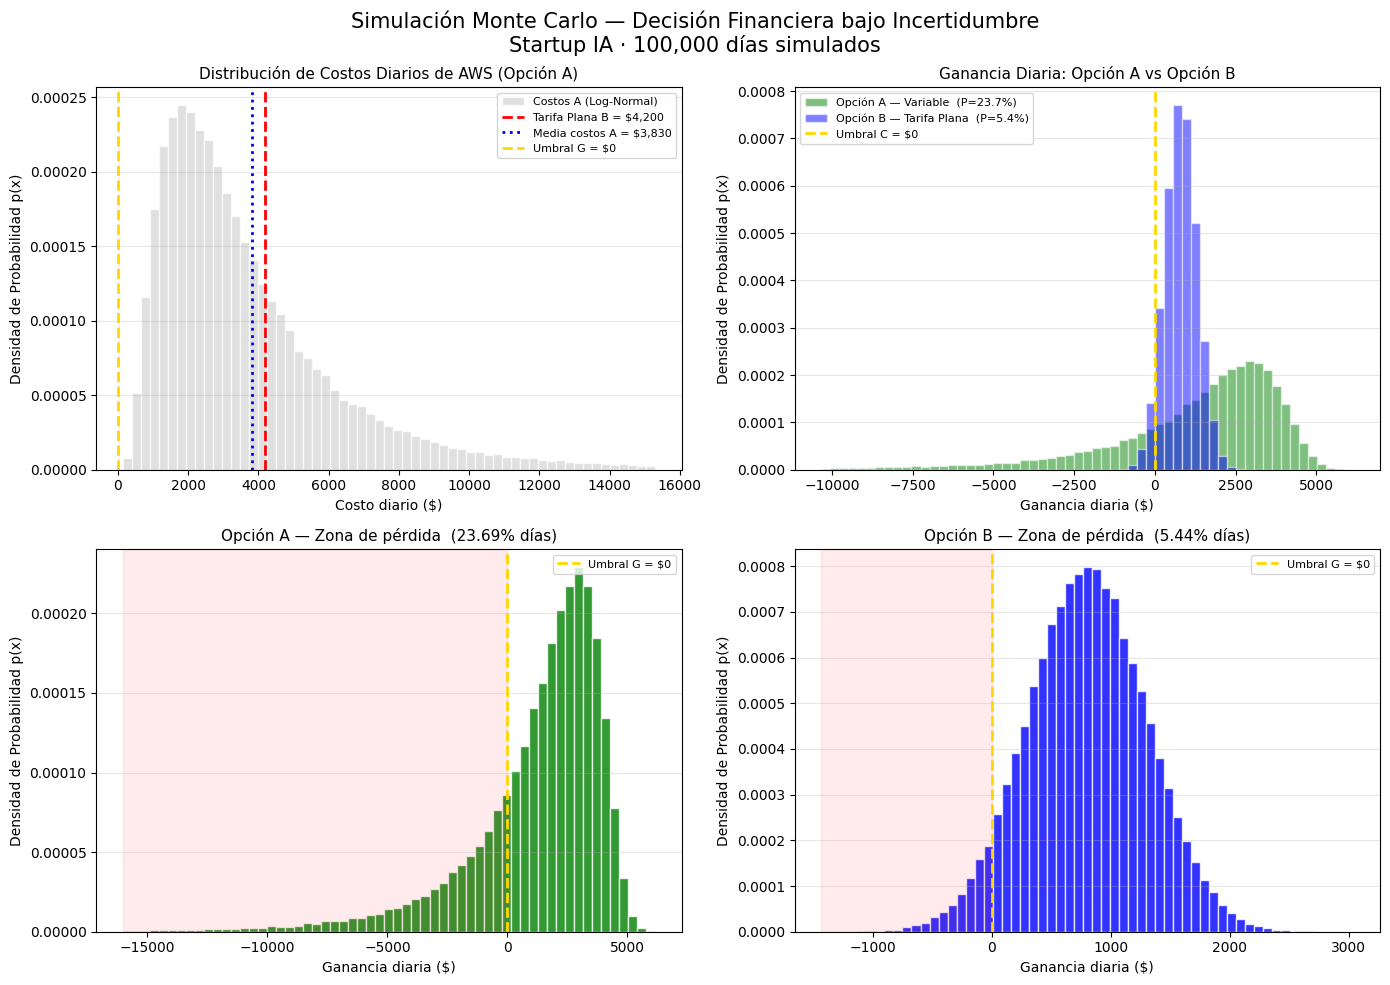

In [ ]:
# =============================================================================
# SECCIÓN 6: VISUALIZACIONES
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]   # fila 1, columna 1 → costos AWS
ax2 = axes[0, 1]   # fila 1, columna 2 → ganancias A vs B
ax3 = axes[1, 0]   # fila 2, columna 1 → zona pérdida Opción A
ax4 = axes[1, 1]   # fila 2, columna 2 → zona pérdida Opción B

# ── GRÁFICA 1: Distribución de costos AWS ──────────────────────────────────
bins_c = np.linspace(costos_A.min(), np.percentile(costos_A, 99), 60)
ax1.hist(costos_A, bins=bins_c, density=True,
         color='lightgray', edgecolor='white', alpha=0.7, label='Costos A (Log-Normal)')
ax1.axvline(TARIFA_PLANA, color='red',  lw=2, linestyle='--', label=f'Tarifa Plana B = ${TARIFA_PLANA:,}')
ax1.axvline(C_MEDIA,      color='blue', lw=2, linestyle=':',  label=f'Media costos A = ${C_MEDIA:,}')
ax1.axvline(0, color='gold', lw=2, linestyle='--', label='Umbral G = $0')
ax1.set_title('Distribución de Costos Diarios de AWS (Opción A)', fontsize=11)
ax1.set_xlabel('Costo diario ($)')
ax1.set_ylabel('Densidad de Probabilidad p(x)')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# ── GRÁFICA 2: Distribución de ganancias — comparación A vs B ──────────────
lim_min2 = np.percentile(ganancia_A, 1)
#lim_max2 = np.percentile(ganancia_A, 99)
lim_max2 = ganancia_A.max()
bins_g = np.linspace(lim_min2, lim_max2, 60)
ax2.hist(ganancia_A, bins=bins_g, density=True,
         color='green', edgecolor='white', alpha=0.5, label=f'Opción A — Variable  (P={stats_A["prob_perdida"]:.1f}%)')
ax2.hist(ganancia_B, bins=bins_g, density=True,
         color='blue', edgecolor='white', alpha=0.5, label=f'Opción B — Tarifa Plana  (P={stats_B["prob_perdida"]:.1f}%)')
ax2.axvline(0, color='gold', lw=2, linestyle='--', label='Umbral C = $0')
ax2.set_title('Ganancia Diaria: Opción A vs Opción B', fontsize=11)
ax2.set_xlabel('Ganancia diaria ($)')
ax2.set_ylabel('Densidad de Probabilidad p(x)')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# ── GRÁFICA 3: Zona de pérdida — Opción A ──────────────────────────────────
perdidas_A = ganancia_A[ganancia_A < 0]
bins_A = np.linspace(np.percentile(perdidas_A, 1), ganancia_A.max(), 60)
ax3.hist(ganancia_A, bins=bins_A, density=True,color='green', edgecolor='white', alpha=0.8)
ax3.axvspan(bins_A[0], 0, color='red', alpha=0.08)
ax3.axvline(0, color='gold', lw=2, linestyle='--', label='Umbral G = $0')
ax3.set_title(f'Opción A — Zona de pérdida  ({stats_A["prob_perdida"]:.2f}% días)', fontsize=11)
ax3.set_xlabel('Ganancia diaria ($)')
ax3.set_ylabel('Densidad de Probabilidad p(x)')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── GRÁFICA 4: Zona de pérdida — Opción B ──────────────────────────────────
perdidas_B = ganancia_B[ganancia_B < 0]
bins_B = np.linspace(perdidas_B.min(),ganancia_B.max(), 60)
ax4.hist(ganancia_B, bins=bins_B, density=True,color='blue', edgecolor='white', alpha=0.8)
ax4.axvspan(bins_B[0], 0, color='red', alpha=0.08)
ax4.axvline(0, color='gold', lw=2, linestyle='--', label='Umbral G = $0')
ax4.set_title(f'Opción B — Zona de pérdida  ({stats_B["prob_perdida"]:.2f}% días)', fontsize=11)
ax4.set_xlabel('Ganancia diaria ($)')
ax4.set_ylabel('Densidad de Probabilidad p(x)')
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)

fig.suptitle('Simulación Monte Carlo — Decisión Financiera bajo Incertidumbre\n'
             'Startup IA · 100,000 días simulados', fontsize=15)
plt.tight_layout()
plt.show()

# **Reto 2: Decisiones Basadas en Datos**

Cuando tenemos suficientes datos reales, a menudo los usamos directamente para simular escenarios futuros. Esta técnica se llama **Bootstrapping** (muestreo con reemplazo).

### Contexto del Negocio

Un restaurante está considerando reformar su política salarial para los meseros. Sabemos que en un turno típico nocturno, **un mesero atiende exactamente a 20 mesas**.

Para este análisis, intervendrán **dos variables aleatorias** de nuestro dataset sobre las cuentas de un restaurante: el total de la cuenta (`total_bill`) y la propina dejada (`tip`).

* **Opción A (Modelo Tradicional):** El mesero gana *exclusivamente* las propinas dejadas por los clientes.

* **Opción B (Modelo "Servicio Incluido"):** Se prohíben las propinas. A cambio, el restaurante garantiza al mesero un **16% fijo** sobre el monto total de cada cuenta que atienda.

**Entregable:** Simular 10.000 turnos de trabajo usando los datos reales para responder: ¿Qué modelo tiene una mayor ganancia esperada? Y lo más importante para la estabilidad del empleado: ¿Cuál modelo tiene menor **riesgo** de que un mesero termine su turno con menos de $60 dólares en el bolsillo?

In [ ]:
# --- CÓDIGO PROBLEMA RESTAURANTE ---
# =============================================================================
# SECCIÓN 1: IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
# =============================================================================
# SECCIÓN 2: CARGAR EL DATASET REAL
# =============================================================================
# Este dataset contiene información sobre cuentas de restaurante y propinas
df_restaurante = sns.load_dataset('tips')

# =============================================================================
# SECCIÓN 3: PARÁMETROS DE LA SIMULACIÓN
# =============================================================================
N_TURNOS   = 10000   # número de turnos a simular
MESAS      = 20       # mesas por turno
PORCENTAJE = 0.16     # 16% fijo — Opción B
UMBRAL     = 60       # mínimo aceptable por turno ($60)

# =============================================================================
# SECCIÓN 4: BOOTSTRAPPING — SIMULACIÓN DE 10,000 TURNOS
# =============================================================================

# Semilla para reproducibilidad
#np.random.seed(42)

# se crea dos arrays vacíos donde se guarda la ganancia total de cada turno
ganancia_A = np.zeros(N_TURNOS)   # Opción A: solo propinas
ganancia_B = np.zeros(N_TURNOS)   # Opción B: 16% del total de cuenta

n_filas = len(df_restaurante)     # total de filas disponibles en el dataset

for turno in range(N_TURNOS):
   # Elegimos 20 índices al azar CON reemplazo
   indices = np.random.choice(n_filas, size=MESAS, replace=True) # permite volver a escoger un indice
   # Extraemos las 20 mesas sorteadas (total_bill y tip juntos)
   mesas_turno =  df_restaurante.iloc[indices]
   # Opción A: el mesero se queda con las propinas reales de esas 20 mesas
   ganancia_A[turno] = mesas_turno['tip'].sum()
   # Opción B: el mesero recibe el 16% del total de cada cuenta
   ganancia_B[turno] = (mesas_turno['total_bill'] * PORCENTAJE).sum()

# =============================================================================
# SECCIÓN 5: ANÁLISIS ESTADÍSTICO
# =============================================================================
def analizar(ganancia, nombre):
    n = len(ganancia)
    dias_perdida  = np.sum(ganancia < UMBRAL)
    prob_perdida  = dias_perdida / n * 100.0
    return {
        "nombre"       : nombre,
        "media"        : float(np.mean(ganancia)),
        "mediana"      : float(np.median(ganancia)),
        "std"          : float(np.std(ganancia)),
        "var"          : float(np.var(ganancia)),
        "sesgo"        : float(skew(ganancia)),
        "curtosis"     : float(kurtosis(ganancia)),
        "turnos_riesgo": int(dias_perdida),
        "prob_riesgo"  : float(prob_perdida),
        "min"          : float(np.min(ganancia)),
        "max"          : float(np.max(ganancia)),
    }

stats_A = analizar(ganancia_A, "Opción A — Modelo Tradicional")
stats_B = analizar(ganancia_B, "Opción B — Servicio Incluido")

# =============================================================================
# SECCIÓN 6: IMPRESIÓN DE RESULTADOS
# =============================================================================
def imprimir_stats(s):
    print(f"\n{'='*65}")
    print(f"  {s['nombre']}")
    print(f"{'='*65}")
    print(f"  Ganancia media por turno :  ${s['media']:>10,.2f}")
    print(f"  Ganancia mediana         :  ${s['mediana']:>10,.2f}")
    print(f"  Desviación estándar      :  ${s['std']:>10,.2f}")
    print(f"  Varianza                 :  ${s['var']:>10,.2f}")
    print(f"  Sesgo                    :  {s['sesgo']:>11.4f}")
    print(f"  Curtosis                 :  {s['curtosis']:>11.4f}")
    print(f"  Ganancia mínima          :  ${s['min']:>10,.2f}")
    print(f"  Ganancia máxima          :  ${s['max']:>10,.2f}")
    print(f"  {'-'*61}")
    print(f"  Turnos bajo (G<$60)      :  {s['turnos_riesgo']:>8,d}  de {N_TURNOS:,}")
    print(f"  Probabilidad riesgo      :  {s['prob_riesgo']:>8.2f} %")
    print(f"{'='*65}")


imprimir_stats(stats_A)
prob_A_mejor_que_B = np.mean(ganancia_A > ganancia_B) * 100
print(f"  Probabilidad de que A tenga mayor ganancia que B: {prob_A_mejor_que_B:.2f}%")

imprimir_stats(stats_B)
prob_B_mejor_que_A = np.mean(ganancia_A < ganancia_B) * 100
print(f"  Probabilidad de que B tenga mayor ganancia que A: {prob_B_mejor_que_A:.2f}%")

# Decisión final
print(f"\n{'='*65}")
print("  DECISIÓN:")
print(f"{'='*65}")
ganadora_ganancia = "A" if stats_A["media"] > stats_B["media"] else "B"
ganadora_riesgo   = "A" if stats_A["prob_riesgo"] < stats_B["prob_riesgo"] else "B"
print(f"  Mayor ganancia esperada  →  Opción {ganadora_ganancia}")
print(f"  Menor riesgo (G<$60)     →  Opción {ganadora_riesgo}")
print(f"{'='*65}\n")


  Opción A — Modelo Tradicional
  Ganancia media por turno :  $     59.91
  Ganancia mediana         :  $     59.56
  Desviación estándar      :  $      6.16
  Varianza                 :  $     37.93
  Sesgo                    :       0.3016
  Curtosis                 :       0.1118
  Ganancia mínima          :  $     40.50
  Ganancia máxima          :  $     90.23
  -------------------------------------------------------------
  Turnos bajo (G<$60)      :     5,284  de 10,000
  Probabilidad riesgo      :     52.84 %
  Probabilidad de que A tenga mayor ganancia que B: 25.64%

  Opción B — Servicio Incluido
  Ganancia media por turno :  $     63.31
  Ganancia mediana         :  $     63.06
  Desviación estándar      :  $      6.38
  Varianza                 :  $     40.66
  Sesgo                    :       0.2486
  Curtosis                 :       0.0997
  Ganancia mínima          :  $     42.33
  Ganancia máxima          :  $     92.80
  -----------------------------------------------

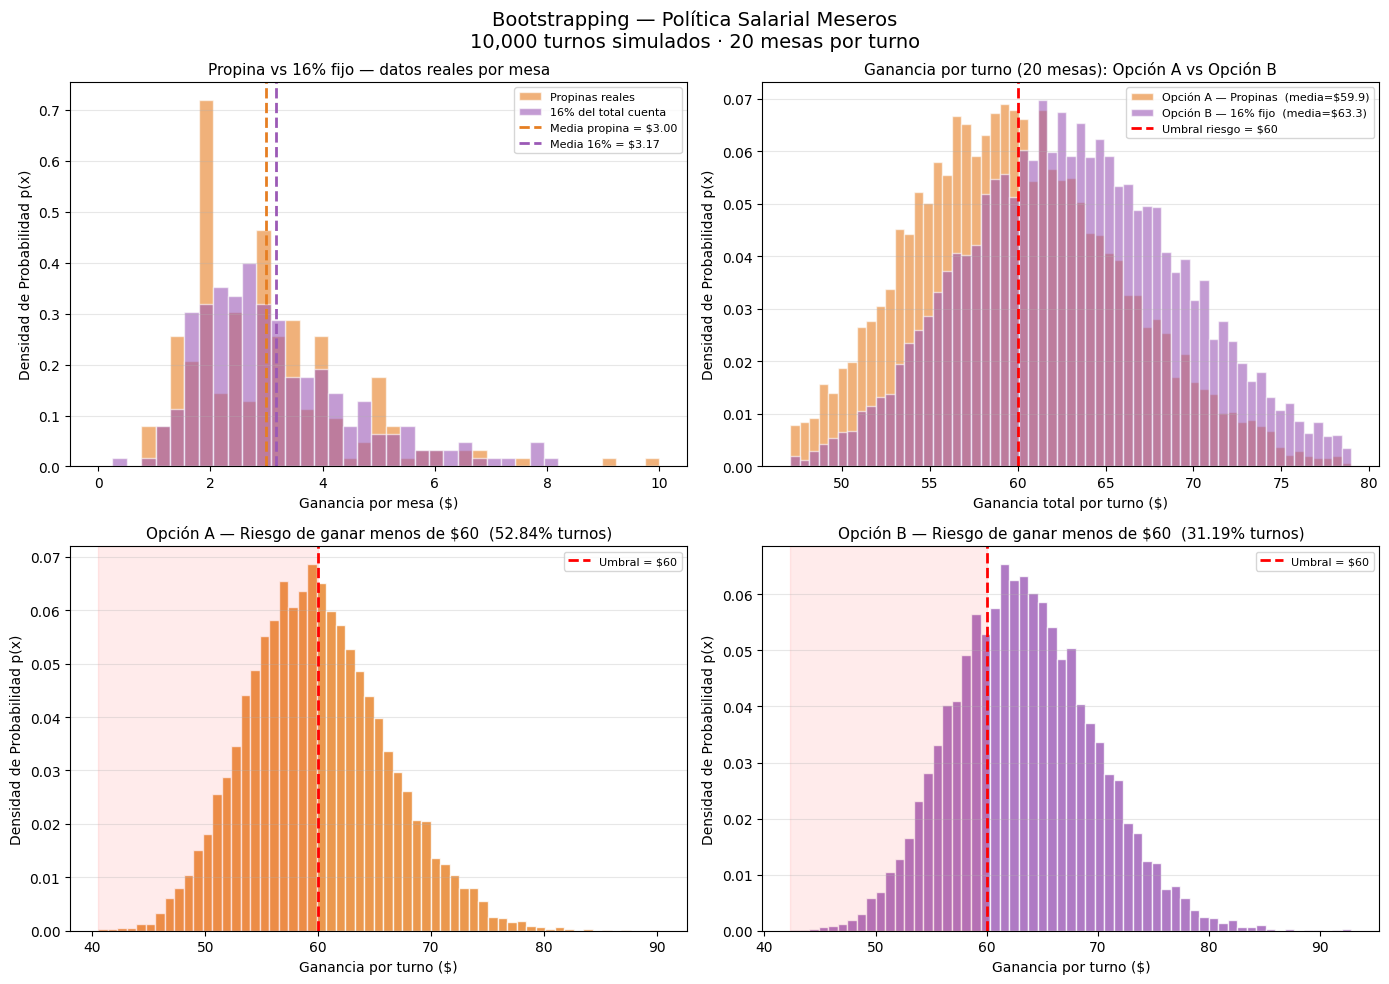

In [ ]:

# =============================================================================
# SECCIÓN 7: VISUALIZACIONES
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]   # distribución propinas reales del dataset
ax2 = axes[0, 1]   # distribución ganancias A vs B por turno
ax3 = axes[1, 0]   # zona de riesgo Opción A (< $60)
ax4 = axes[1, 1]   # zona de riesgo Opción B (< $60)

# ── GRÁFICA 1: Distribución de propinas y 16% en el dataset real ───────────
porc_real = df_restaurante['total_bill'] * PORCENTAJE
bins_raw  = np.linspace(0, max(df_restaurante['tip'].max(), porc_real.max()), 40)

ax1.hist(df_restaurante['tip'], bins=bins_raw, density=True,color='#e67e22', edgecolor='white', alpha=0.6,
         label='Propinas reales')
ax1.hist(porc_real, bins=bins_raw, density=True,color='#9b59b6', edgecolor='white', alpha=0.6,
         label='16% del total cuenta')
ax1.axvline(df_restaurante['tip'].mean(),  color='#e67e22', lw=2, linestyle='--',
            label=f"Media propina = ${df_restaurante['tip'].mean():.2f}")
ax1.axvline(porc_real.mean(), color='#9b59b6', lw=2, linestyle='--',
            label=f"Media 16% = ${porc_real.mean():.2f}")
ax1.set_title('Propina vs 16% fijo — datos reales por mesa', fontsize=11)
ax1.set_xlabel('Ganancia por mesa ($)')
ax1.set_ylabel('Densidad de Probabilidad p(x)')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# ── GRÁFICA 2: Ganancias simuladas por turno (20 mesas) ────────────────────
lim_min2 = min(np.percentile(ganancia_A, 1), np.percentile(ganancia_B, 1))
lim_max2 = max(np.percentile(ganancia_A, 99), np.percentile(ganancia_B, 99))
bins_g   = np.linspace(lim_min2, lim_max2, 60)

ax2.hist(ganancia_A, bins=bins_g, density=True,
         color='#e67e22', edgecolor='white', alpha=0.6,
         label=f'Opción A — Propinas  (media=${stats_A["media"]:.1f})')
ax2.hist(ganancia_B, bins=bins_g, density=True,
         color='#9b59b6', edgecolor='white', alpha=0.6,
         label=f'Opción B — 16% fijo  (media=${stats_B["media"]:.1f})')
ax2.axvline(UMBRAL, color='red', lw=2, linestyle='--', label=f'Umbral riesgo = ${UMBRAL}')
ax2.set_title('Ganancia por turno (20 mesas): Opción A vs Opción B', fontsize=11)
ax2.set_xlabel('Ganancia total por turno ($)')
ax2.set_ylabel('Densidad de Probabilidad p(x)')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# ── GRÁFICA 3: Zona de riesgo Opción A ─────────────────────────────────────
#riesgo_A = ganancia_A[ganancia_A < UMBRAL]
bins_A   = np.linspace(ganancia_A.min(), ganancia_A.max(), 60)
ax3.hist(ganancia_A, bins=bins_A, density=True,
         color='#e67e22', edgecolor='white', alpha=0.8)
ax3.axvspan(ganancia_A.min(), UMBRAL, color='red', alpha=0.08)
ax3.axvline(UMBRAL, color='red', lw=2, linestyle='--', label=f'Umbral = ${UMBRAL}')
ax3.set_title(f'Opción A — Riesgo de ganar menos de ${UMBRAL}  ({stats_A["prob_riesgo"]:.2f}% turnos)', fontsize=11)
ax3.set_xlabel('Ganancia por turno ($)')
ax3.set_ylabel('Densidad de Probabilidad p(x)')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── GRÁFICA 4: Zona de riesgo Opción B ─────────────────────────────────────
#riesgo_B = ganancia_B[ganancia_B < UMBRAL]
bins_B   = np.linspace(ganancia_B.min(), ganancia_B.max(), 60)
ax4.hist(ganancia_B, bins=bins_B, density=True,
         color='#9b59b6', edgecolor='white', alpha=0.8)
ax4.axvspan(ganancia_B.min(), UMBRAL, color='red', alpha=0.08)
ax4.axvline(UMBRAL, color='red', lw=2, linestyle='--', label=f'Umbral = ${UMBRAL}')
ax4.set_title(f'Opción B — Riesgo de ganar menos de ${UMBRAL}  ({stats_B["prob_riesgo"]:.2f}% turnos)', fontsize=11)
ax4.set_xlabel('Ganancia por turno ($)')
ax4.set_ylabel('Densidad de Probabilidad p(x)')
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)

fig.suptitle('Bootstrapping — Política Salarial Meseros\n10,000 turnos simulados · 20 mesas por turno',
             fontsize=14)
plt.tight_layout()
plt.show()